In [3]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

# =====================================
# Load Dataset
# =====================================

df = pd.read_csv(
    r"C:\A-CMSI research\Data\HMM data\HMM_Input_features.csv"
)

# =====================================
# Features
# =====================================

features = [
    "SPY_Return",
    "SPY_V",
    "RollingVol21",
    "RollingSkew21",
    "Drawdown",
    "VolOfVol",
    "VIX",
    "C_t"
]

X = df[features]

# =====================================
# Standardize Features
# =====================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# =====================================
# Train 2-State Full Covariance HMM
# =====================================

best_model = None
best_score = -np.inf

for seed in range(30):

    model = GaussianHMM(
        n_components=2,
        covariance_type="full",
        n_iter=200,
        random_state=seed
    )

    model.fit(X_scaled)

    score = model.score(X_scaled)

    if score > best_score:

        best_score = score
        best_model = model

print("="*60)
print("Best Log-Likelihood:", best_score)
print("="*60)

# =====================================
# Hidden States
# =====================================

hidden_states = best_model.predict(X_scaled)

df["State"] = hidden_states

# =====================================
# State Means
# =====================================

print("\nSTATE MEANS\n")

print(
    df.groupby("State")[[
        "SPY_Return",
        "SPY_V",
        "RollingVol21",
        "RollingSkew21",
        "Drawdown",
        "VolOfVol",
        "VIX",
        "C_t"
    ]].mean()
)

# =====================================
# Transition Matrix
# =====================================

print("\nTRANSITION MATRIX\n")

print(best_model.transmat_)

# =====================================
# Model Selection Statistics
# =====================================

logL = best_model.score(X_scaled)

n_states = best_model.n_components
n_features = X_scaled.shape[1]
n_samples = X_scaled.shape[0]

# Number of Parameters (Full Covariance)

k = (
    (n_states - 1)
    + n_states * (n_states - 1)
    + n_states * n_features
    + n_states * n_features * (n_features + 1) / 2
)

AIC = -2 * logL + 2 * k

BIC = -2 * logL + np.log(n_samples) * k

print("\nMODEL SELECTION")

print("----------------------------")
print("Number of States :", n_states)
print("Log-Likelihood   :", logL)
print("Parameters       :", int(k))
print("AIC              :", AIC)
print("BIC              :", BIC)
print("----------------------------")

Best Log-Likelihood: -17528.68888445328

STATE MEANS

       SPY_Return     SPY_V  RollingVol21  RollingSkew21  Drawdown  VolOfVol  \
State                                                                          
0        0.001021 -0.614430      0.006063      -0.150716 -0.005939  0.000917   
1        0.000049  0.484427      0.013020      -0.188035 -0.084782  0.002106   

             VIX       C_t  
State                       
0      14.827664  0.554018  
1      22.389689  0.757521  

TRANSITION MATRIX

[[0.98266255 0.01733745]
 [0.0192809  0.9807191 ]]

MODEL SELECTION
----------------------------
Number of States : 2
Log-Likelihood   : -17528.68888445328
Parameters       : 91
AIC              : 35239.37776890656
BIC              : 35769.83792982303
----------------------------


In [4]:
print(df["State"].value_counts().sort_index())

State
0    1293
1    1220
Name: count, dtype: int64


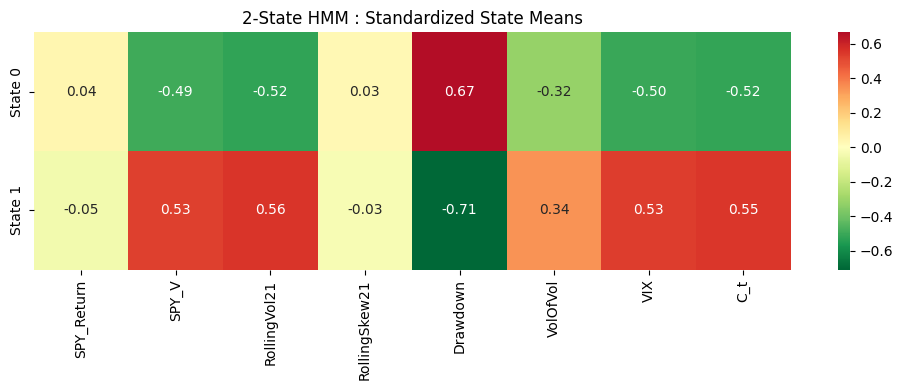

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

features = [
    "SPY_Return",
    "SPY_V",
    "RollingVol21",
    "RollingSkew21",
    "Drawdown",
    "VolOfVol",
    "VIX",
    "C_t"
]

state_names = [
    "State 0",
    "State 1"
]

means = pd.DataFrame(
    best_model.means_,
    columns=features,
    index=state_names
)

plt.figure(figsize=(10,4))

sns.heatmap(
    means,
    annot=True,
    cmap="RdYlGn_r",
    center=0,
    fmt=".2f"
)

plt.title("2-State HMM : Standardized State Means")

plt.tight_layout()

plt.show()

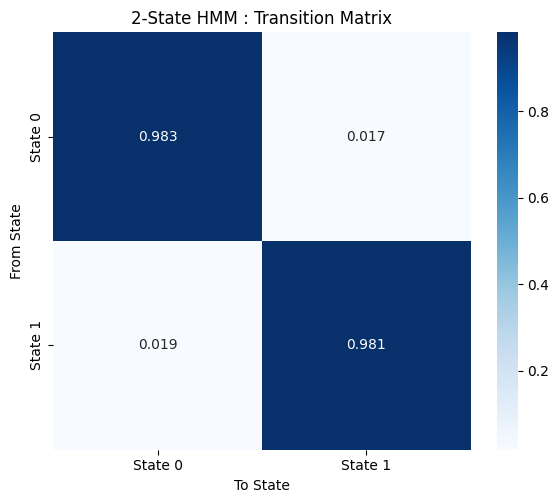

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

trans = pd.DataFrame(
    best_model.transmat_,
    index=["State 0","State 1"],
    columns=["State 0","State 1"]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    trans,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    square=True,
    cbar=True
)

plt.title("2-State HMM : Transition Matrix")
plt.xlabel("To State")
plt.ylabel("From State")

plt.tight_layout()
plt.show()

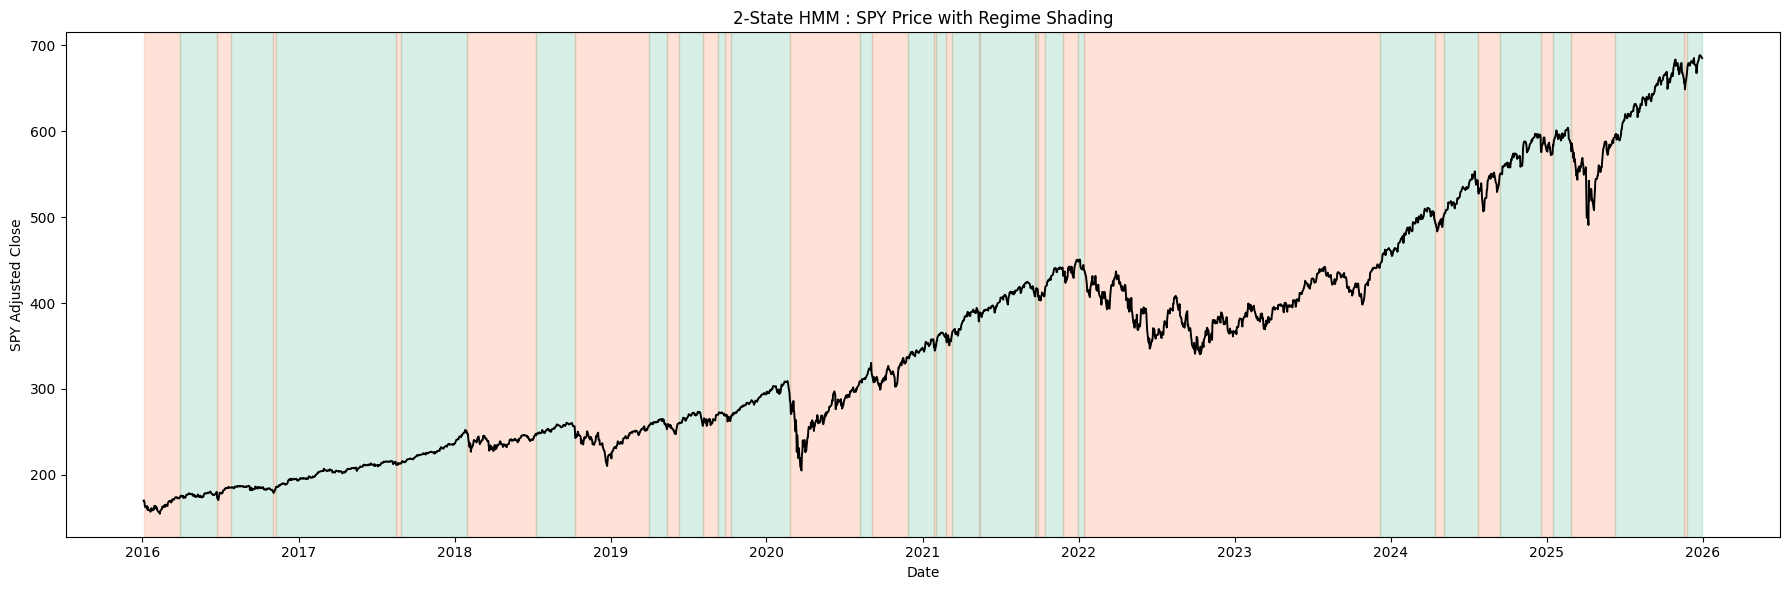

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load prices
prices = pd.read_csv(
    r"C:/A-CMSI research/Data/prices_clean.csv"
)

prices["Date"] = pd.to_datetime(prices["Date"], dayfirst=True)
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Merge SPY prices with HMM states
plot_df = prices.merge(
    df[["Date", "State"]],
    on="Date",
    how="inner"
)

# Colors for 5 states
colors = [
    "#66c2a5",   # State 0
    "#fc8d62",   # State 1
]

fig, ax = plt.subplots(figsize=(18,6))

# SPY Price
ax.plot(
    plot_df["Date"],
    plot_df["SPY"],
    color="black",
    linewidth=1.4,
    label="SPY"
)

# Shade regimes
current_state = plot_df["State"].iloc[0]
start_date = plot_df["Date"].iloc[0]

for i in range(1, len(plot_df)):

    if plot_df["State"].iloc[i] != current_state:

        ax.axvspan(
            start_date,
            plot_df["Date"].iloc[i],
            color=colors[current_state],
            alpha=0.25
        )

        current_state = plot_df["State"].iloc[i]
        start_date = plot_df["Date"].iloc[i]

# Shade final regime
ax.axvspan(
    start_date,
    plot_df["Date"].iloc[-1],
    color=colors[current_state],
    alpha=0.25
)

plt.title("2-State HMM : SPY Price with Regime Shading")
plt.xlabel("Date")
plt.ylabel("SPY Adjusted Close")

plt.tight_layout()
plt.show()

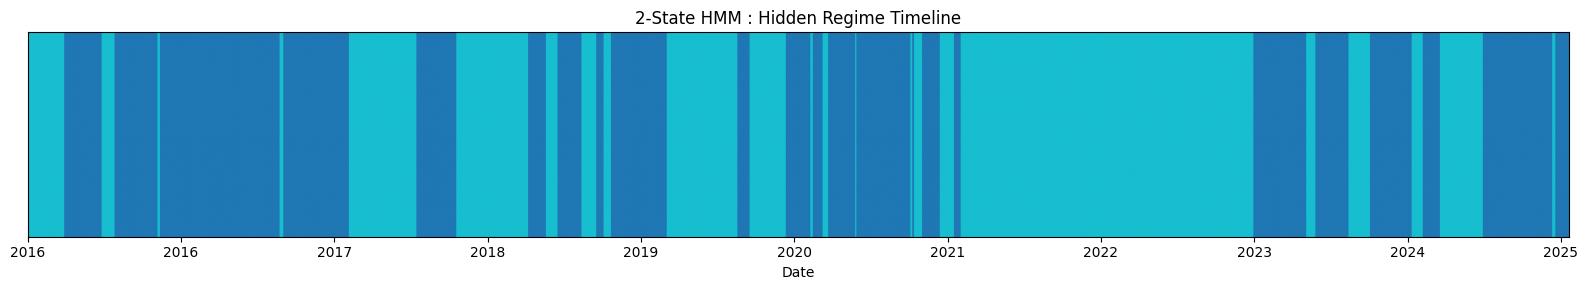

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

dates = pd.to_datetime(df["Date"])

plt.figure(figsize=(16,3))

plt.imshow(
    [df["State"]],
    aspect="auto",
    cmap="tab10",
    extent=[0, len(df), 0, 1]
)

ticks = range(0, len(df), 250)

plt.xticks(
    ticks,
    dates.iloc[ticks].dt.strftime("%Y"),
    rotation=0
)

plt.yticks([])

plt.title(f"{best_model.n_components}-State HMM : Hidden Regime Timeline")

plt.xlabel("Date")

plt.tight_layout()

plt.show()

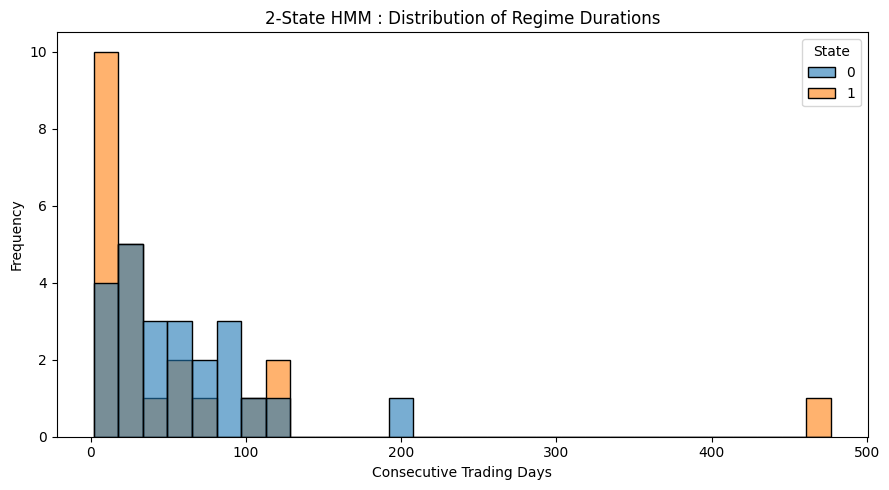

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------
# Calculate regime durations
# -------------------------------------

durations = []

current_state = df["State"].iloc[0]
length = 1

for state in df["State"].iloc[1:]:

    if state == current_state:
        length += 1

    else:
        durations.append([current_state, length])
        current_state = state
        length = 1

durations.append([current_state, length])

duration_df = pd.DataFrame(
    durations,
    columns=["State", "Duration"]
)

# -------------------------------------
# Histogram
# -------------------------------------

plt.figure(figsize=(9,5))

sns.histplot(
    data=duration_df,
    x="Duration",
    hue="State",
    bins=30,
    multiple="layer",
    alpha=0.6
)

plt.title(f"{best_model.n_components}-State HMM : Distribution of Regime Durations")

plt.xlabel("Consecutive Trading Days")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()